In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
data = pd.read_csv('housing.csv')

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [4]:
data.dropna(inplace=True)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.7+ MB


In [6]:
from sklearn.model_selection import train_test_split  
x = data.drop('median_house_value', axis=1)
y = data['median_house_value']  

In [7]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

In [8]:
train_data = x_train.join(y_train)

In [9]:
train_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
6297,-117.90,34.02,15.0,14058.0,2486.0,8997.0,2497.0,5.0704,<1H OCEAN,226200.0
15667,-122.44,37.80,52.0,2869.0,594.0,500.0,335.0,5.0376,NEAR BAY,500001.0
11447,-117.97,33.66,14.0,6090.0,1338.0,1974.0,1248.0,2.8061,<1H OCEAN,180300.0
12245,-116.97,33.74,20.0,3674.0,792.0,1498.0,758.0,2.2161,INLAND,76900.0
8881,-118.49,34.03,30.0,4061.0,927.0,1487.0,865.0,4.1827,<1H OCEAN,435100.0
...,...,...,...,...,...,...,...,...,...,...
16341,-121.33,38.03,10.0,629.0,140.0,635.0,146.0,2.2961,INLAND,126700.0
793,-122.09,37.64,36.0,1180.0,212.0,664.0,200.0,5.2838,NEAR BAY,172600.0
10998,-117.80,33.76,27.0,2655.0,345.0,1017.0,335.0,6.9014,<1H OCEAN,366800.0
15338,-117.29,33.20,16.0,2150.0,461.0,1428.0,407.0,2.4754,NEAR OCEAN,157300.0


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

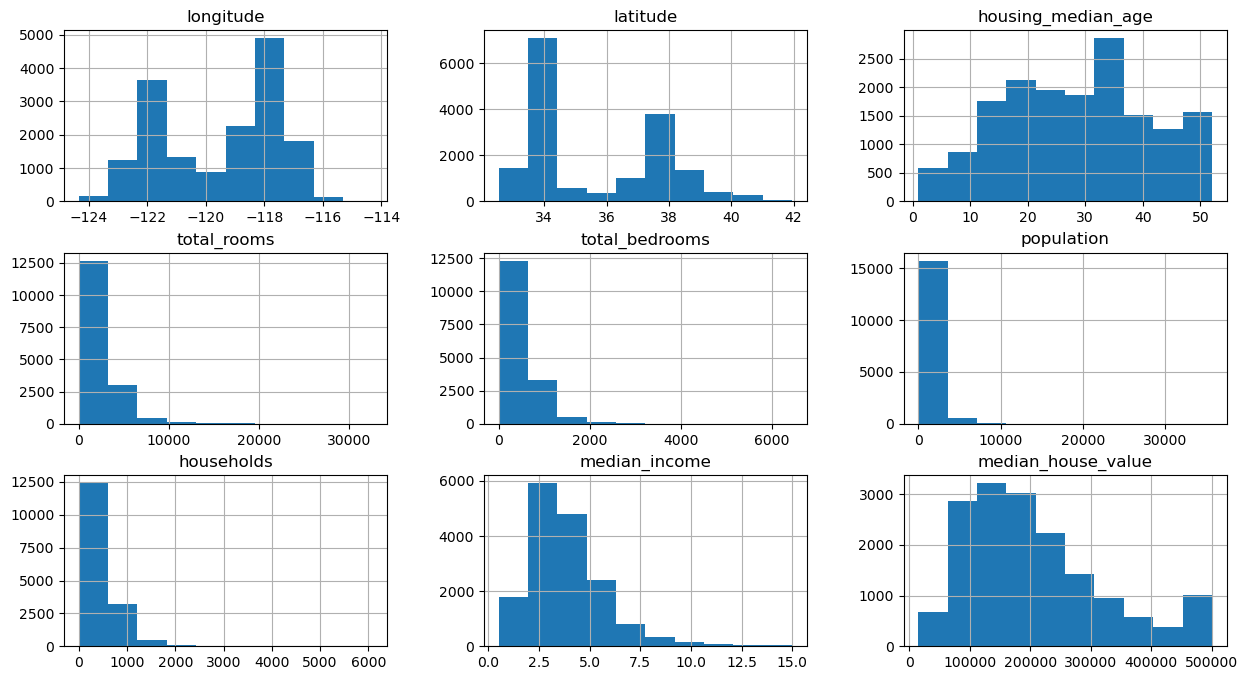

In [10]:
train_data.hist(figsize=(15, 8))

<Axes: >

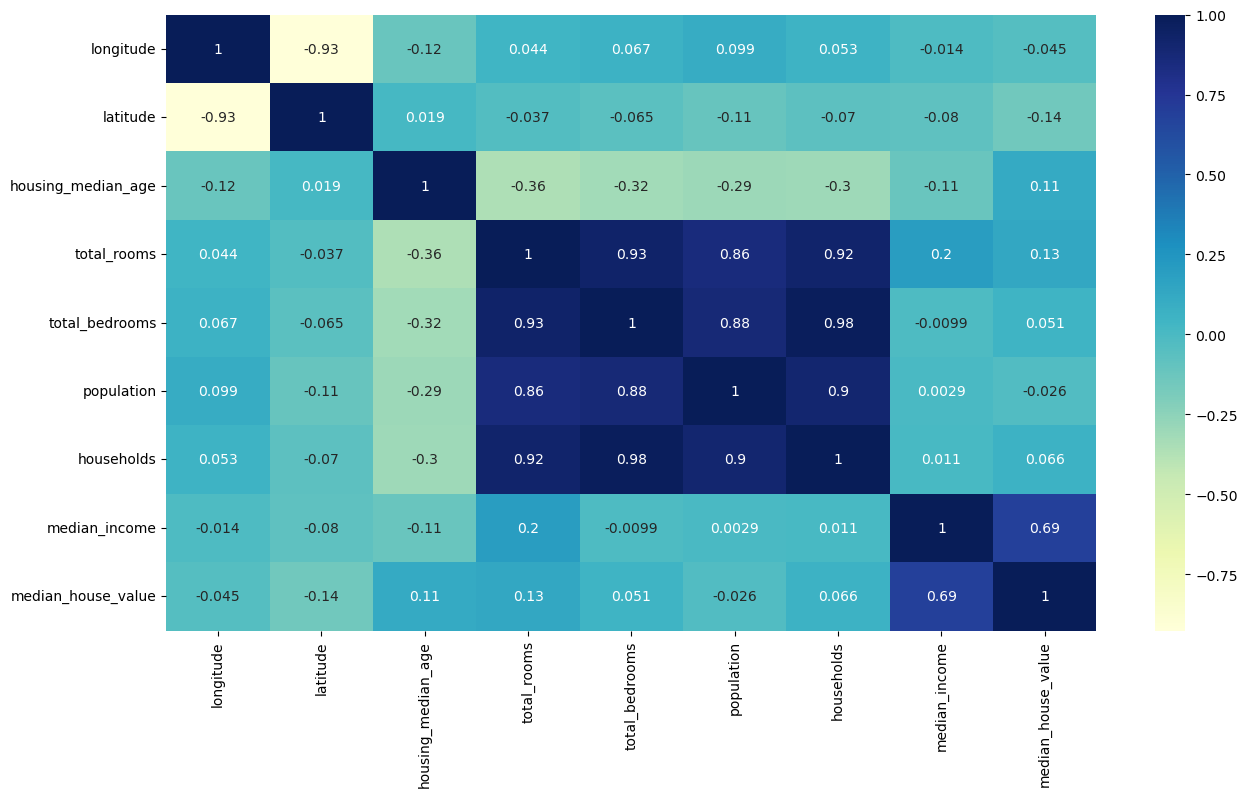

In [11]:
plt.figure(figsize=(15, 8))
sns.heatmap(train_data.corr(numeric_only=True), annot=True, cmap='YlGnBu')

In [12]:
train_data['total_rooms'] = np.log(train_data['total_rooms']+1)
train_data['total_bedrooms'] = np.log(train_data['total_bedrooms']+1)
train_data['population'] = np.log(train_data['population']+1)
train_data['households'] = np.log(train_data['households']+1)

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

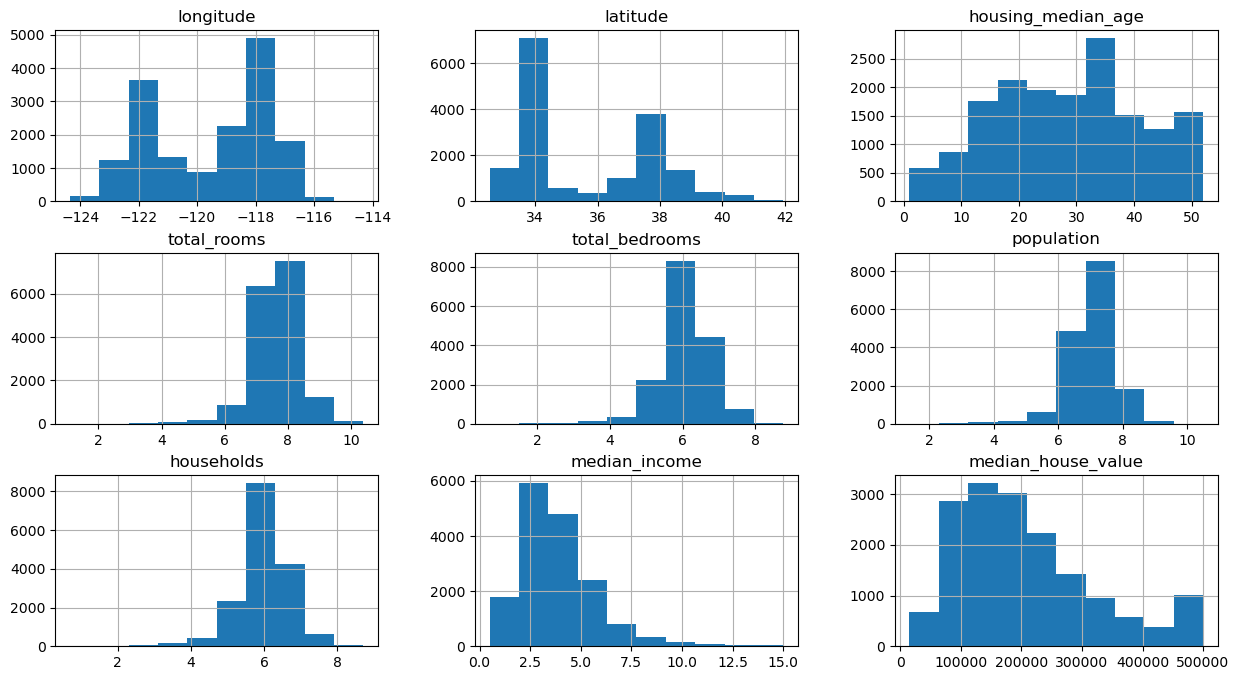

In [13]:
train_data.hist(figsize=(15, 8))

In [14]:
train_data.ocean_proximity.value_counts()

ocean_proximity
<1H OCEAN     7194
INLAND        5173
NEAR OCEAN    2123
NEAR BAY      1852
ISLAND           4
Name: count, dtype: int64

In [15]:
train_data = train_data.join(pd.get_dummies(train_data.ocean_proximity)).drop('ocean_proximity', axis=1)

In [16]:
train_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
6297,-117.90,34.02,15.0,9.551018,7.818832,9.104758,7.823246,5.0704,226200.0,True,False,False,False,False
15667,-122.44,37.80,52.0,7.962067,6.388561,6.216606,5.817111,5.0376,500001.0,False,False,False,True,False
11447,-117.97,33.66,14.0,8.714568,7.199678,7.588324,7.130099,2.8061,180300.0,True,False,False,False,False
12245,-116.97,33.74,20.0,8.209308,6.675823,7.312553,6.632002,2.2161,76900.0,False,True,False,False,False
8881,-118.49,34.03,30.0,8.309431,6.833032,7.305188,6.763885,4.1827,435100.0,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16341,-121.33,38.03,10.0,6.445720,4.948760,6.455199,4.990433,2.2961,126700.0,False,True,False,False,False
793,-122.09,37.64,36.0,7.074117,5.361292,6.499787,5.303305,5.2838,172600.0,False,False,False,True,False
10998,-117.80,33.76,27.0,7.884577,5.846439,6.925595,5.817111,6.9014,366800.0,True,False,False,False,False
15338,-117.29,33.20,16.0,7.673688,6.135565,7.264730,6.011267,2.4754,157300.0,False,False,False,False,True


<Axes: >

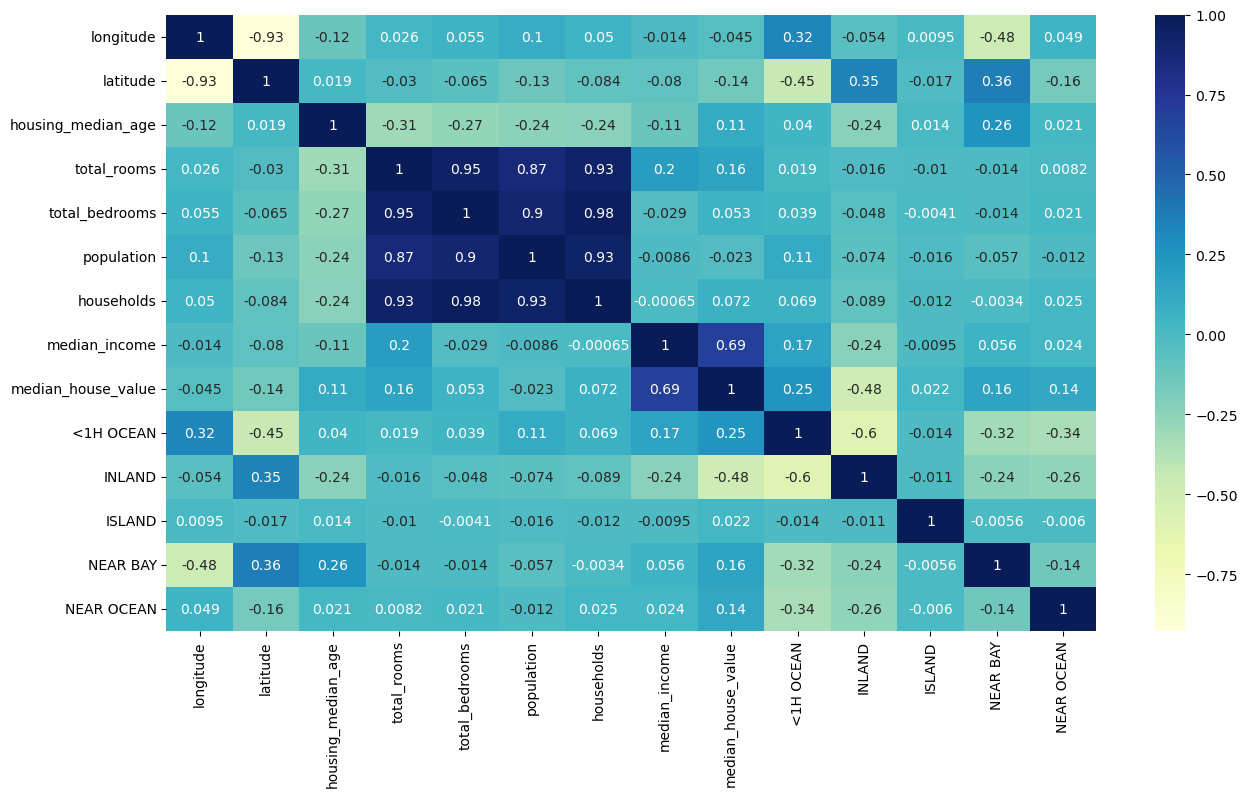

In [17]:
plt.figure(figsize=(15, 8))
sns.heatmap(train_data.corr(), annot=True, cmap='YlGnBu')

<Axes: xlabel='latitude', ylabel='longitude'>

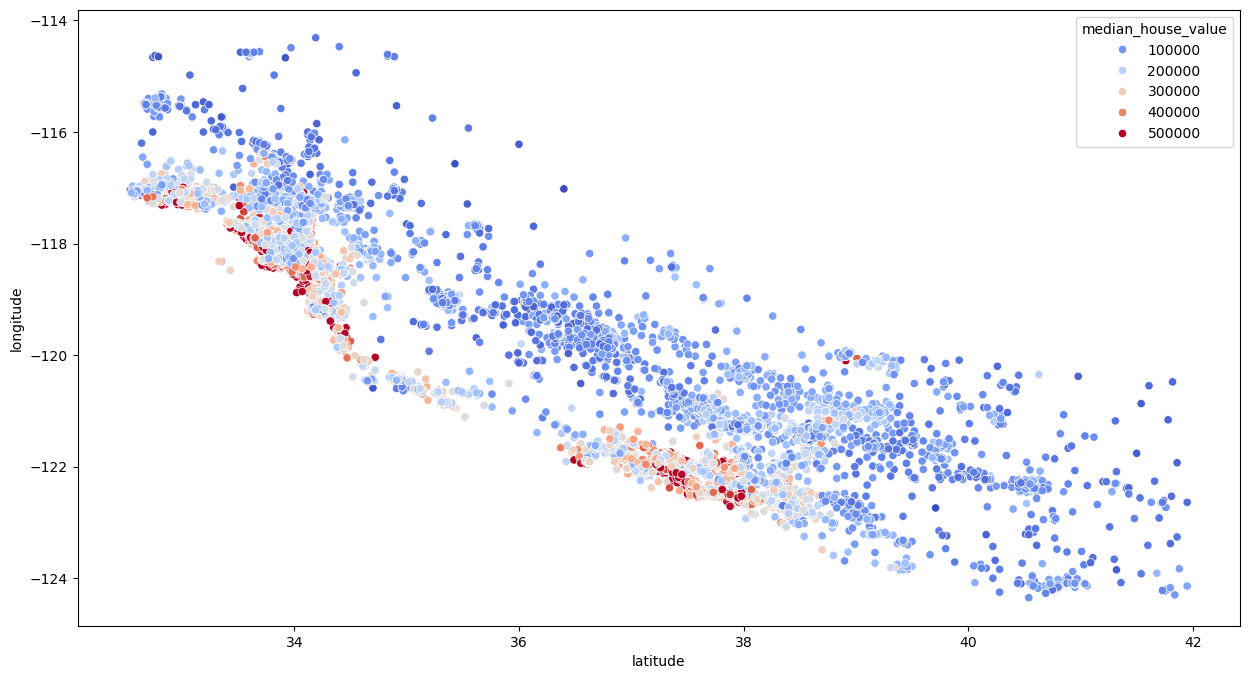

In [18]:
plt.figure(figsize=(15, 8))
sns.scatterplot(x='latitude', y='longitude', data=train_data,hue='median_house_value', palette='coolwarm')

In [19]:
train_data['bedroom_ratio'] = train_data['total_bedrooms']/train_data['total_rooms']
train_data['household_rooms'] = train_data['total_rooms']/train_data['households']

<Axes: >

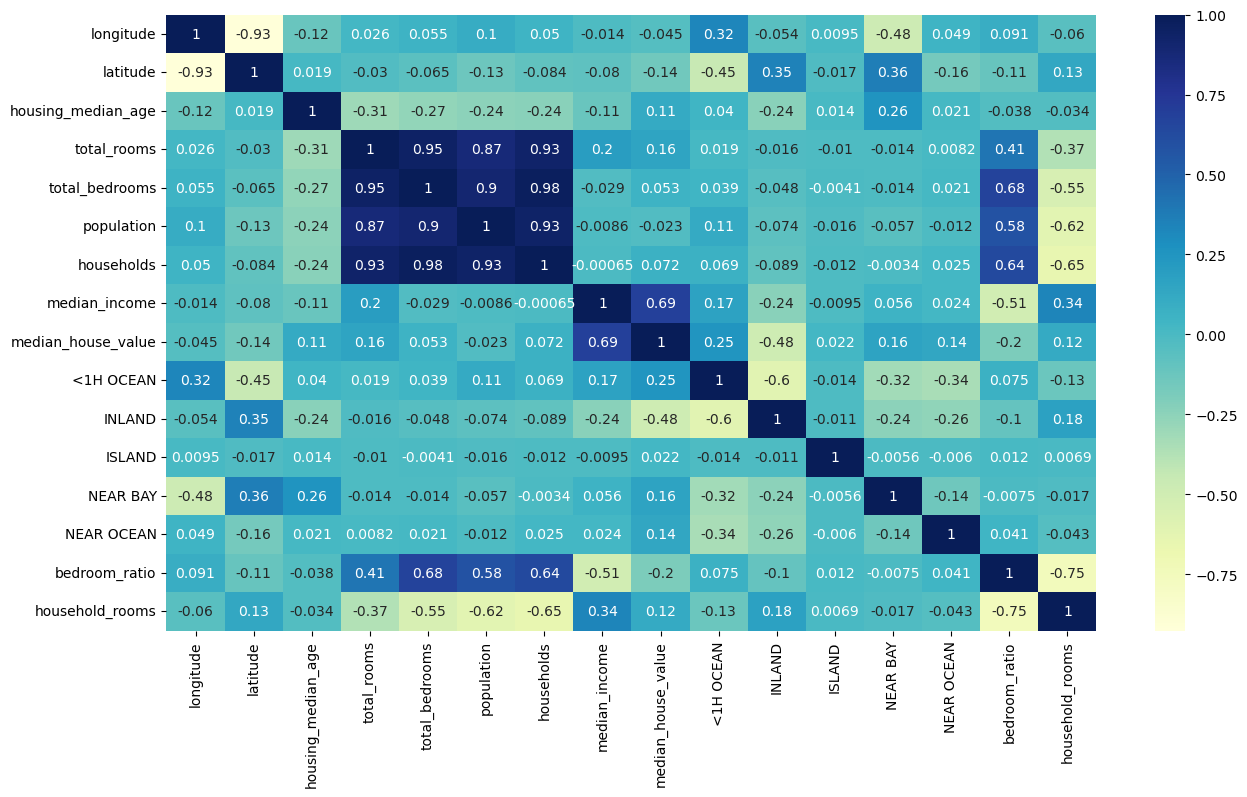

In [20]:
plt.figure(figsize=(15, 8))
sns.heatmap(train_data.corr(), annot=True, cmap='YlGnBu')

In [21]:
from sklearn.linear_model import LinearRegression
x_train,y_train = train_data.drop('median_house_value', axis=1), train_data['median_house_value']
reg = LinearRegression()
reg.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [22]:
test_data = x_test.join(y_test)

test_data['total_rooms'] = np.log(test_data['total_rooms']+1)
test_data['total_bedrooms'] = np.log(test_data['total_bedrooms']+1)
test_data['population'] = np.log(test_data['population']+1)
test_data['households'] = np.log(test_data['households']+1)

test_data = test_data.join(pd.get_dummies(test_data.ocean_proximity)).drop('ocean_proximity', axis=1)

test_data['bedroom_ratio'] = test_data['total_bedrooms']/test_data['total_rooms']
test_data['household_rooms'] = test_data['total_rooms']/test_data['households']

In [23]:
test_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN,bedroom_ratio,household_rooms
8983,-118.43,33.99,45.0,7.646354,6.113682,7.082549,6.063785,3.8021,323000.0,True,False,False,False,False,0.799555,1.260987
9798,-121.91,36.55,39.0,8.606851,6.727432,7.486053,6.569481,5.7248,398800.0,False,False,False,False,True,0.781637,1.310126
17958,-121.98,37.33,35.0,7.553811,5.789960,6.816736,5.749393,5.9567,294300.0,True,False,False,False,False,0.766495,1.313845
7278,-118.25,33.98,47.0,6.426488,5.093750,6.626718,4.976734,2.2969,116700.0,True,False,False,False,False,0.792618,1.291306
17911,-121.98,37.36,33.0,7.367077,5.609472,6.697034,5.590987,5.7059,287200.0,True,False,False,False,False,0.761424,1.317670
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5710,-118.23,34.21,38.0,7.244228,5.968708,6.756932,5.958425,3.4148,234800.0,True,False,False,False,False,0.823926,1.215796
11298,-117.91,33.78,33.0,7.912057,6.309918,7.707063,6.284134,4.0362,177900.0,True,False,False,False,False,0.797507,1.259053
18700,-122.34,40.58,7.0,8.485496,6.900731,7.707063,6.838405,3.0549,101700.0,False,True,False,False,False,0.813238,1.240859
16055,-122.49,37.76,52.0,7.232010,5.442418,6.563856,5.634790,5.8096,339800.0,False,False,False,True,False,0.752546,1.283457


In [24]:
x_test,y_test = test_data.drop('median_house_value', axis=1), test_data['median_house_value']

In [28]:
reg.score(x_test, y_test)

0.6663958736766534

In [29]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor()
rf.fit(x_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [30]:
rf.score(x_test, y_test)

0.8147503464626875

In [31]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [3, 10, 30],
    'max_features': [2, 4, 6, 8]
}
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5,scoring='neg_mean_squared_error',return_train_score=True)
grid_search.fit(x_train, y_train)

,estimator,RandomForestRegressor()
,param_grid,"{'max_features': [2, 4, ...], 'n_estimators': [3, 10, ...]}"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,n_estimators,30


In [32]:
best_rf = grid_search.best_estimator_

In [33]:
best_rf.score(x_test, y_test)

0.8080604674969345